# 6.1 Importação e Visualização do banco de Dados

In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
np.random.seed(0)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier


 `import pandas as pd` 
 - importa biblioteca para manipular dados dos dataframes

`import matplotlib.pylot as plt` 
- importa biblioteca para criar gráficos

`importseaborn as sns` 
- gráficos mais bonitos baseados em matplotlib

`%matplotlib inline`
- Comando Jupyter que fará a exibição de gráficos diretamente na célula

`np.random.seed(0)`
- Define uma semente fixa para resultados produziveis, ou seja, resultados gerados por funções sejam reproduzidas de forma igual, toda vez que o código for executado

In [315]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [316]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [317]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Análise Exploratória Preliminar

In [318]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


`train`
- lê o arquivo CSV de treino e carrega o DataFrame

`test`
- lê o arquivo CSV de teste e carrega o DataFrame

`train.head()`
- Mostra as primeiras 5 linhas do DataFrame

`test.describe()`
- exibe estatísticas descritivas

`test.info`
- Mostra o tipo de dados, NaN e uso da memória

Ao analisarmos, chegamos às seguintes conclusões:

## Variáveis Numéricas
- Age(Discreta)
- SibSp(Discreta)
- Parch(Discreta)
- Fare(Contínua)

## Variáveis Categóricas
- Survived
- Pclass(1,2,3)
- Sex
- Embarked

## Variáveis de Identificação
- PassengerID
- Name
- Ticket
- Cabin

Agora Iremos Checar os Valores Ausentes (Nan)

In [319]:
print("Train:")
print(train.isnull().sum())
print("\nTest:")
print(test.isnull().sum())

Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


`print(train.isnull().sum())`
- Conta quantos valores ausentes há em cada coluna do treino

`print(test.isnull().sum())`
- Conta quantos valores ausentes há em cada coluna do teste

Concluimos que `Age`, `Cabin` e `Embarked` têm valores ausentes no train e `Age` e `Fare` no test

### Criação de novos dataframes contendo apenas as features numericas (para train e test) e Remoção de linhas com valores faltantes no conjunto de treino

In [320]:
train_numeric=['Age','SibSp', 'Parch', 'Fare','Survived']
test_numeric= ['Age','SibSp', 'Parch', 'Fare']

train= train[train_numeric].dropna()
test= test[test_numeric].fillna(0)

`train_numeric`
- Cria uma lista com os nomes das colunas que usei. Essas são as colunas numéricas importantes para o modelo

`test_numeric`
- Cria uma lista das colunas numéricas para teste. Note que a feature 'Survived' não está incluida, pois é o que queremos prever

`train= train[train_numeric].dropna()`
- seleciona apenas colunas listadas em train_numeric e a partir do uso de .dropna() remove todas as linhas com valores NaN. Por fim, o resultado é armazenado de volta em 'train'

`test= test[test_numeric].fillna(0)`
- seleciona apenas as colunas listadas e preenche os valores faltantes com 0


# 6.2 Exploração do Banco de Dados

Temos como objetivo visualizar a influencia das features nas taxas de sobreviveencia. Para isso, serao criados  graficos com sns.barplot, que comparam medias de    sobrevivencia para diferentes faixas ou categorias.

## `AGE`

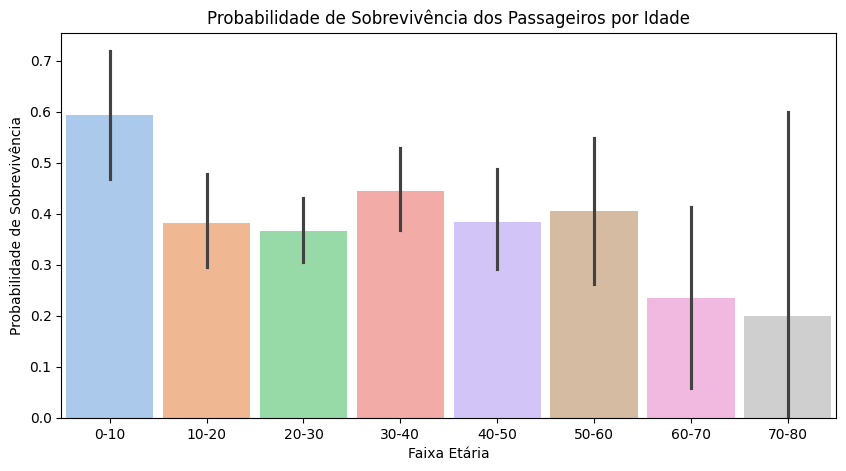

In [321]:
age_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
train['Faixa Etária'] = pd.cut(train['Age'], bins=bins, labels=age_labels)
test['Faixa Etária'] = pd.cut(test['Age'], bins=bins, labels=age_labels)
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Faixa Etária',
    y='Survived',
    data=train,
    hue='Faixa Etária',
    palette='pastel',
    legend=False,
    dodge=False,
    width=0.9
)

plt.title('Probabilidade de Sobrevivência dos Passageiros por Idade')
plt.xlabel('Faixa Etária')
plt.ylabel('Probabilidade de Sobrevivência')



plt.show()

Através do gráfico concluimos que a taxa de sobrevivência varia de acordo com a idade. Crianças de 0–10 anos tiveram a maior taxa de sobrevivência, enquanto pessoas entre 70–80 anos tiveram uma das menores. Isso sugere que a idade pode influenciar a sobrevivência, embora outras variáveis também tenham participação nesse resultado.

`age_labels`
- Cria uma lista com rótulos para as faixas etárias

`bins`
- Cria uma lista com os limites das faixas etária

`train['Faixa Etária'] = pd.cut(train['Age'], bins=bins, labels=age_labels)`
- pd.cut() divide a coluna Age em intervalos com labels especificados
- Cria uma nova coluna `Faixa Etaria` no DataFrame Train
- Pegamos como exemplo caso a idade seja 15, ela vira: 10-20 e assim por diante com outras idades

`test['Faixa Etária'] = pd.cut(test['Age'], bins=bins, labels=age_labels)`
- faz o mesmo do supracitado, só que agora para o DataFrame test

`plt.figure(figsize=(10, 5))`
- Cria um gráfico com tamanho 10 de largura por 5 de altura

`sns.barplot`
- irá criar um grafico de barras


## `SibSp`

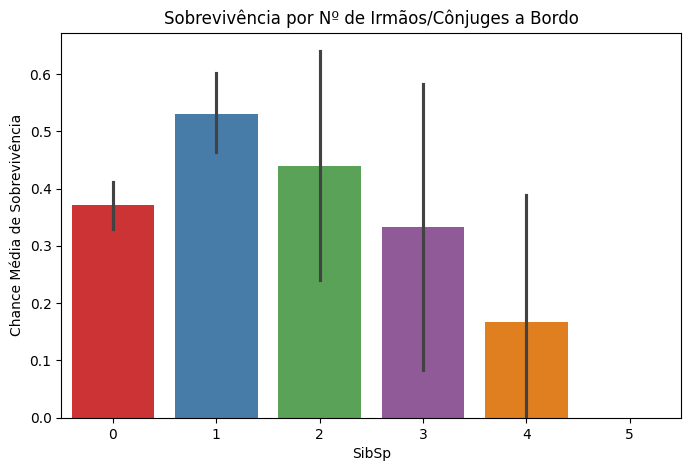

In [322]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='SibSp',
    y='Survived',
    data=train,
    hue='SibSp',
    palette='Set1',
    legend=False
)

plt.title('Sobrevivência por Nº de Irmãos/Cônjuges a Bordo')
plt.ylabel('Chance Média de Sobrevivência')
plt.xlabel('SibSp')
plt.show()

Analisando o gráfico concluimos que: os passageiros que tinham entre 1 ou 2 acompanhantes a bordo tiveram maior taxa de sobrevivencia

## `Parch`

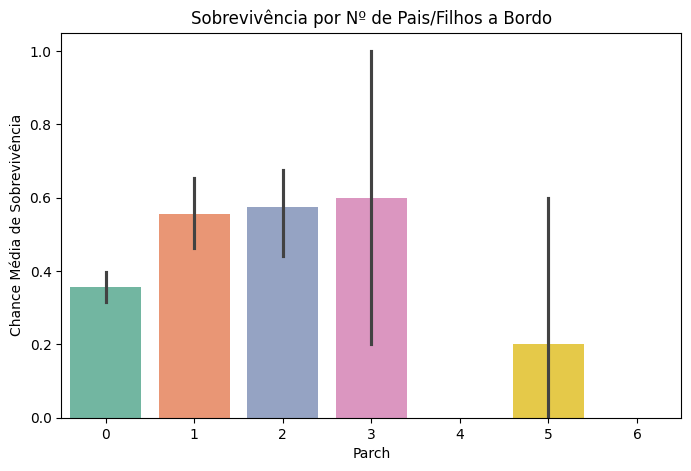

In [323]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Parch',
    y='Survived',
    data=train,
    hue='Parch',
    palette='Set2',
    legend=False
)

plt.title('Sobrevivência por Nº de Pais/Filhos a Bordo')
plt.ylabel('Chance Média de Sobrevivência')
plt.xlabel('Parch')

plt.show()

# 6.3 Treinamento do modelo e submissão das predições

Agora, será contruido o primeiro modelo preditivo.

In [324]:
from sklearn.model_selection import train_test_split

feature_cols = ['Age', 'SibSp', 'Parch', 'Fare']

X = train[feature_cols]
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

``feature_cols = ['Age', 'SibSp', 'Parch', 'Fare']``
- define quais colunas serão usadas como features (variáveis preditoras). Note que só foram escolhidas as numéricas mais simples.``

``X = train[feature_cols] ``
- cria a matriz de entrada X só com essas colunas.

``y = train['Survived'] ``
- target, o que se quer prever: sobreviveu ou não

``train_test_split(X, y, test_size=0.2, random_state=0)`` 
- separa 80% dos dados para treino e 20% para validação, com random_state=0 para garantir reprodutibilidad

In [325]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

preds_val = model.predict(X_val)
acc_cap6_inicial = accuracy_score(y_val, preds_val)
acc_cap6_inicial 



0.6503496503496503

In [326]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

feature_cols = ['Age', 'SibSp', 'Parch', 'Fare']

X = train[feature_cols]
y = train['Survived']

model_v1 = RandomForestClassifier(n_estimators=100, random_state=0)
model_v1.fit(X, y)

test_v1 = test.copy()
test_v1['Age'] = test_v1['Age'].fillna(train['Age'].median())
test_v1['Fare'] = test_v1['Fare'].fillna(train['Fare'].median())

X_test_v1 = test_v1[feature_cols]

preds_v1 = model_v1.predict(X_test_v1)

submission_v1 = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': preds_v1
})

submission_v1.to_csv('submission_v1_065.csv', index=False)
submission_v1.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,0


``model.fit(X_train, y_train)``
- treina o modelo usando os dados de treino.

``model.predict(X_val)``
- gera as previsões para os dados de validação.

``accuracy_score(y_val, preds_val)``
- compara as previsões com os valores reais e calcula a acurácia


#### Esse foi o modelo mais simples possível, usou apenas 4 variáveis numéricas (Age, SibSp, Parch, Fare) e ignorou completamente Sex e Pclass, que são historicamente as variáveis mais importantes no Titanic (mulheres e passageiros de 1ª classe tinham muito mais chance de sobreviver). Uma acurácia de 65% é pouco melhor que o acaso (cerca de 61-62% no dataset do Titanic, já que ~62% dos passageiros morreram). Ou seja, o modelo quase não aprendeu nada de útil, ele confirma que a escolha das features é mais importante do que o algoritmo em si nesse estágio.

# Segundo Método

In [327]:
train_2 = pd.read_csv('train.csv')
test_2 = pd.read_csv('test.csv')

train_2.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [328]:
age_mediana = train_2['Age'].median()
fare_mediana = train_2['Fare'].median()

train_2['Age'] = train_2['Age'].fillna(age_mediana)
test_2['Age'] = test_2['Age'].fillna(age_mediana)
test_2['Fare'] = test_2['Fare'].fillna(fare_mediana)

- Calcula a mediana de Age e Fare no treino.
- Preenche (fillna) os valores ausentes de Age no treino e no teste com essa mediana.
- Preenche o único valor ausente de Fare no teste (o treino não tinha Fare ausente).

 Ao invés de descartar linhas com NaN, os dados ausentes são imputados, preservando mais informação.

In [329]:
from sklearn.model_selection import train_test_split
numeric_cols_2 = train.select_dtypes(include=np.number).columns.tolist()
feature_cols_2 = [c for c in numeric_cols_2 if c not in ['PassengerId', 'Survived']]

X = train_2[feature_cols_2]
y = train_2['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

``select_dtypes(include=np.number)`` : pega automaticamente todas as colunas numéricas do dataframe train (não apenas as 4 escolhidas manualmente antes).

- Remove PassengerId e Survived da lista de features (a primeira é só um identificador, a segunda é o alvo).

- Monta X e y e faz a mesma divisão treino/validação.

In [330]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

preds_val = model.predict(X_val)
accuracy_score(y_val, preds_val)  

0.7262569832402235

# Modelo final

In [331]:
train_3 = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train_3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [332]:
print("Train:")
print(train.isnull().sum())
print("\nTest:")
print(test.isnull().sum())

Train:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Test:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


 Quando foi Seguido estritamente o roteiro, notamos que a predição não resultou em uma análise muito satisfatoria, haja visto que não ultrapassou muito o acaso. Podemos melhorar o código, a partir de uma análise percebemos que não usamos as features mais importantes, sendo elas: `Sex` e `PClass`. Então para melhorar o código, vamos aumentar as features e ver os resultados.

In [333]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

train_3 = train_3[features + ['Survived']].copy()
test_3 = test[features].copy()


train_3['Age'] = train_3['Age'].fillna(train_3['Age'].median())
test_3['Age'] = test_3['Age'].fillna(test_3['Age'].median())


test_3['Fare'] = test_3['Fare'].fillna(test_3['Fare'].median())


train_3['Embarked'] = train_3['Embarked'].fillna(train_3['Embarked'].mode()[0])


train_3['Sex'] = train_3['Sex'].map({'male': 0, 'female': 1})
test_3['Sex'] = test_3['Sex'].map({'male': 0, 'female': 1})


train_3 = pd.get_dummies(train_3, columns=['Embarked'], drop_first=True)
test_3 = pd.get_dummies(test_3, columns=['Embarked'], drop_first=True)

``features``: agora inclui Pclass, Sex e Embarked, além das numéricas anteriores.

- Seleciona só essas colunas + Survived (no treino).

- Preenche Age com a mediana (treino e teste).

- Preenche Fare ausente no teste com a mediana.

- Preenche Embarked ausente no treino com a moda (valor mais frequente — 'S').

- map({'male': 0, 'female': 1}) : converte Sex, que é texto, em número (0 ou 1), pois modelos de ML não trabalham com texto diretamente.

- pd.get_dummies(..., columns=['Embarked'], drop_first=True), transforma Embarked (que tem 3 categorias: C, Q, S) em colunas binárias (Embarked_Q, Embarked_S), descartando uma categoria (drop_first=True) para evitar redundância (dummy variable trap).

In [334]:
from sklearn.model_selection import train_test_split
feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
X = train_3[feature_cols]
y = train_3['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

X_3 = train_3[feature_cols]
y_3 = train_3['Survived']

- Define as colunas finais de features (agora incluindo as versões codificadas de Sex e Embarked).

- Faz a divisão treino/validação.

- Guarda X_3/y_3 (usados depois na seção de comparação de vários modelos).

In [335]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

preds_val = model.predict(X_val)
accuracy_score(y_val, preds_val)  


0.8435754189944135

## Submissão

In [336]:
train_final = pd.read_csv('train.csv')
test_final = pd.read_csv('test.csv')

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

train_final = train_final[features + ['Survived']].copy()
test_final_feat = test_final[features].copy()

train_final['Age'] = train_final['Age'].fillna(train_final['Age'].median())
test_final_feat['Age'] = test_final_feat['Age'].fillna(train_final['Age'].median())

test_final_feat['Fare'] = test_final_feat['Fare'].fillna(train_final['Fare'].median())

train_final['Embarked'] = train_final['Embarked'].fillna(train_final['Embarked'].mode()[0])

train_final['Sex'] = train_final['Sex'].map({'male': 0, 'female': 1})
test_final_feat['Sex'] = test_final_feat['Sex'].map({'male': 0, 'female': 1})

train_final = pd.get_dummies(train_final, columns=['Embarked'], drop_first=True)
test_final_feat = pd.get_dummies(test_final_feat, columns=['Embarked'], drop_first=True)

feature_cols_final = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

for col in ['Embarked_Q', 'Embarked_S']:
    if col not in test_final_feat.columns:
        test_final_feat[col] = 0

X_final = train_final[feature_cols_final]
y_final = train_final['Survived']

model_final = RandomForestClassifier(n_estimators=100, random_state=0)
model_final.fit(X_final, y_final)

X_test_final = test_final_feat[feature_cols_final]
preds_final = model_final.predict(X_test_final)

submission_final = pd.DataFrame({
    'PassengerId': test_final['PassengerId'],
    'Survived': preds_final
})
submission_final.to_csv('submission_modelo_final_084.csv', index=False)
submission_final.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


#### Ao incluir Sex, Pclass e Embarked (devidamente codificados), a acurácia saltou de 0.73 para 0.84. Isso confirma a hipótese, Sex e Pclass são, de longe, as variáveis mais preditivas no problema do Titanic (mulheres e passageiros de 1ª classe sobreviviam muito mais). O aprendizado principal aqui é que feature selection (escolha certa de variáveis) importa mais do que ajustar hiperparâmetros do modelo, o mesmo algoritmo (Random Forest, 100 árvores) saiu de 65% para 84% de acurácia só mudando quais informações ele recebe.

# Data Cleaning

In [337]:
train_clean = pd.read_csv('train.csv')
test_clean = pd.read_csv('test.csv')


print("Colunas do treino:")
print(train_clean.columns.tolist())
print("\nColunas do teste:")
print(test_clean.columns.tolist())

Colunas do treino:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Colunas do teste:
['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [338]:
print("Tipos de dados - treino:")
print(train_clean.dtypes)
print("\nTipos de dados - teste:")
print(test_clean.dtypes)

Tipos de dados - treino:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Tipos de dados - teste:
PassengerId      int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [339]:
print("Valores nulos - treino:")
print(train_clean.isnull().sum())
print("\nValores nulos - teste:")
print(test_clean.isnull().sum())

Valores nulos - treino:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Valores nulos - teste:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [340]:
train_clean = train_clean.copy()
test_clean = test_clean.copy()

## Tratamento de valores ausentes

In [341]:
train_clean = train_clean.drop(columns=["Cabin", "Ticket"], errors="ignore")
test_clean = test_clean.drop(columns=["Cabin", "Ticket"], errors="ignore")

- Remove Cabin (muitíssimos valores ausentes — quase 77% no treino) e Ticket (código alfanumérico sem padrão útil direto). errors="ignore" evita erro caso a coluna já não exista.

In [342]:

train_clean["Age"] = train_clean["Age"].fillna(train_clean["Age"].median())
test_clean["Age"] = test_clean["Age"].fillna(test_clean["Age"].median())


train_clean["Fare"] = train_clean["Fare"].fillna(train_clean["Fare"].median())
test_clean["Fare"] = test_clean["Fare"].fillna(test_clean["Fare"].median())


train_clean["Embarked"] = train_clean["Embarked"].fillna(train_clean["Embarked"].mode()[0])
test_clean["Embarked"] = test_clean["Embarked"].fillna(test_clean["Embarked"].mode()[0])

print("Nulos após tratamento (treino):")
print(train_clean[["Age", "Fare", "Embarked"]].isnull().sum())
print("\nNulos após tratamento (teste):")
print(test_clean[["Age", "Fare", "Embarked"]].isnull().sum())

Nulos após tratamento (treino):
Age         0
Fare        0
Embarked    0
dtype: int64

Nulos após tratamento (teste):
Age         0
Fare        0
Embarked    0
dtype: int64


- Preenche Age, Fare e Embarked com mediana/moda, de forma padronizada e explícita cada etapa é impressa para conferência).

In [343]:
train_clean["AgeGroup"] = pd.cut(train_clean["Age"], bins=5)
test_clean["AgeGroup"] = pd.cut(test_clean["Age"], bins=5)

print("Distribuição dos grupos de idade (treino):")
print(train_clean["AgeGroup"].value_counts().sort_index())

Distribuição dos grupos de idade (treino):
AgeGroup
(0.34, 16.336]      100
(16.336, 32.252]    523
(32.252, 48.168]    188
(48.168, 64.084]     69
(64.084, 80.0]       11
Name: count, dtype: int64


``pd.cut``
- divide Age em 5 faixas de largura igual (não de frequência igual), criando uma variável categórica (AgeGroup) que pode capturar relações não-lineares entre idade e sobrevivência.

In [344]:
train_clean["FareGroup"] = pd.qcut(train_clean["Fare"], q=6)
test_clean["FareGroup"] = pd.qcut(test_clean["Fare"], q=6)

print("Distribuição dos grupos de tarifa (treino):")
print(train_clean["FareGroup"].value_counts().sort_index())

train_clean.head()

Distribuição dos grupos de tarifa (treino):
FareGroup
(-0.001, 7.775]      156
(7.775, 8.662]       152
(8.662, 14.454]      139
(14.454, 26.0]       149
(26.0, 52.369]       146
(52.369, 512.329]    149
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,"(16.336, 32.252]","(-0.001, 7.775]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,"(32.252, 48.168]","(52.369, 512.329]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,"(16.336, 32.252]","(7.775, 8.662]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,"(32.252, 48.168]","(52.369, 512.329]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,"(32.252, 48.168]","(7.775, 8.662]"


``pd.qcut`` 
- divide Fare em 6 faixas com quantidade igual de passageiros em cada uma (por isso os limites são desiguais) — útil porque Fare é bem distorcida (poucos valores muito altos).

#### Essa etapa organizou de forma sistemática o que antes era feito de modo mais improvisado: remoção de colunas inúteis ou com excesso de nulos, imputação padronizada de valores ausentes, e criação de variáveis categóricas derivadas (AgeGroup, FareGroup) que podem ajudar modelos a capturar padrões não-lineares. O ganho aqui não é uma acurácia numérica imediata, mas sim uma base de dados mais robusta e pronta para engenharia de features mais sofisticada, feita de forma reprodutível e auditável

# Aperfeiçoamento da Modelagem

In [345]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train_clean = train.copy()
test_clean = test.copy()


train_clean = train_clean.drop(columns=['Cabin', 'Ticket'])
test_clean = test_clean.drop(columns=['Cabin', 'Ticket'])


train_clean = train_clean.drop(columns=['Name'])
test_ids = test_clean['PassengerId']
test_clean = test_clean.drop(columns=['Name'])


idade_mediana = train_clean['Age'].median()
fare_mediana = train_clean['Fare'].median()

train_clean['Age'] = train_clean['Age'].fillna(idade_mediana)
test_clean['Age'] = test_clean['Age'].fillna(idade_mediana)
test_clean['Fare'] = test_clean['Fare'].fillna(fare_mediana)


embarked_moda = train_clean['Embarked'].mode()[0]
train_clean['Embarked'] = train_clean['Embarked'].fillna(embarked_moda)

print(train_clean.isnull().sum())
print(test_clean.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64
PassengerId    0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


- Remove Cabin, Ticket e Name (texto livre, sem uso direto em modelos simples), mas guarda test_ids (o PassengerId do teste) para depois montar o arquivo de submissão.

- Imputa Age, Fare e Embarked como antes

## Encoding de Variáveis Categóricas

In [346]:
train_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    str    
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(2)
memory usage: 62.8 KB


In [347]:
colunas_numericas = train_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = train_clean.select_dtypes(include=['object']).columns.tolist()

print("Numéricas:", colunas_numericas)
print("Categóricas:", colunas_categoricas)

Numéricas: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categóricas: ['Sex', 'Embarked']


C:\Users\victo\AppData\Local\Temp\ipykernel_2420\673397376.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = train_clean.select_dtypes(include=['object']).columns.tolist()


In [348]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode(df, columns):


    df_encoded = df.copy()

    for col in columns:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded_array = encoder.fit_transform(df_encoded[[col]])
        encoded_cols = encoder.get_feature_names_out([col])

        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df_encoded.index)

        df_encoded = df_encoded.drop(columns=[col])
        df_encoded = pd.concat([df_encoded, encoded_df], axis=1)

    return df_encoded

train_clean = one_hot_encode(train_clean, ['Embarked'])
test_clean = one_hot_encode(test_clean, ['Embarked'])

train_clean.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,male,22.0,1,0,7.2500,0.0,0.0,1.0
1,2,1,1,female,38.0,1,0,71.2833,1.0,0.0,0.0
2,3,1,3,female,26.0,0,0,7.9250,0.0,0.0,1.0
3,4,1,1,female,35.0,1,0,53.1000,0.0,0.0,1.0
4,5,0,3,male,35.0,0,0,8.0500,0.0,0.0,1.0


- Função manual que aplica OneHotEncoder a uma lista de colunas, criando uma coluna binária para cada categoria (ex.: Embarked_C, Embarked_Q, Embarked_S) e concatenando ao dataframe original.

In [349]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(train_clean['Sex'])

train_clean['Sex_Label'] = label_encoder.transform(train_clean['Sex'])
test_clean['Sex_Label'] = label_encoder.transform(test_clean['Sex'])

train_clean = train_clean.drop(columns=['Sex'])
test_clean = test_clean.drop(columns=['Sex'])

train_clean.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Sex_Label
0,1,0,3,22.0,1,0,7.2500,0.0,0.0,1.0,1
1,2,1,1,38.0,1,0,71.2833,1.0,0.0,0.0,0
2,3,1,3,26.0,0,0,7.9250,0.0,0.0,1.0,0
3,4,1,1,35.0,1,0,53.1000,0.0,0.0,1.0,0
4,5,0,3,35.0,0,0,8.0500,0.0,0.0,1.0,1


In [350]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

feature_cols_encoded = [c for c in train_clean.columns if c not in ['PassengerId', 'Survived']]

X_encoded = train_clean[feature_cols_encoded]
y_encoded = train_clean['Survived']

X_train_enc, X_val_enc, y_train_enc, y_val_enc = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=0
)

modelo_encoded = RandomForestClassifier(n_estimators=100, random_state=0)
modelo_encoded.fit(X_train_enc, y_train_enc)

preds_encoded = modelo_encoded.predict(X_val_enc)
acc_encoded = accuracy_score(y_val_enc, preds_encoded)

print(f"Acurácia com variáveis codificadas: {acc_encoded:.4f}")
print(f"Acurácia do modelo anterior (Cap. 6, apenas numéricas): {acc_cap6_inicial:.4f}")

Acurácia com variáveis codificadas: 0.8268
Acurácia do modelo anterior (Cap. 6, apenas numéricas): 0.6503


## Pipelines

In [351]:
train_pipeline = train.copy()
train_pipeline = train_pipeline.drop(columns=['Cabin', 'Ticket', 'Name'])


train_pipeline['Age'] = train['Age']
train_pipeline['Embarked'] = train['Embarked']

print(train_pipeline.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         2
dtype: int64


In [352]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

def avaliar_pipeline(data, encoder, model, numerical_imputer, categorical_imputer):
   
    features = [c for c in data.columns if c not in ['PassengerId', 'Survived']]
    X = data[features]
    y = data['Survived']

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0)

    numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()


    if numerical_imputer == 'zero':
        num_imputer = SimpleImputer(strategy='constant', fill_value=0)
    else:
        num_imputer = SimpleImputer(strategy=numerical_imputer)

    cat_encoder = OneHotEncoder(handle_unknown='ignore') if encoder == 'onehot' else OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1
    )

    
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_imputer, numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy=categorical_imputer)),
            ('encoder', cat_encoder)
        ]), categorical_cols)
    ])

    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    #
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_val)
    acc = accuracy_score(y_val, preds)

    
    return round(acc * 100, 2)

### Estratégias de imputação e de encoding

In [353]:
imputing_strategies_num = ['mean', 'median', 'zero']
imputing_strategies_cat = ['most_frequent']
encoding_strategies = ['onehot', 'ordinal']

### Loop aninhado testando todas as combinações

In [354]:
resultados_pipelines = []

for num_imp in imputing_strategies_num:
    for cat_imp in imputing_strategies_cat:
        for enc in encoding_strategies:
            acc = avaliar_pipeline(
                data=train_pipeline,
                encoder=enc,
                model=RandomForestClassifier(n_estimators=100, random_state=0),
                numerical_imputer=num_imp,
                categorical_imputer=cat_imp
            )
            resultados_pipelines.append({
                'imputer_numerico': num_imp,
                'imputer_categorico': cat_imp,
                'encoder': enc,
                'acuracia': acc
            })
            print(f"num={num_imp:12s} | cat={cat_imp:14s} | encoder={enc:8s} -> acurácia={acc}%")

resultados_pipelines_df = pd.DataFrame(resultados_pipelines).sort_values('acuracia', ascending=False).reset_index(drop=True)
resultados_pipelines_df


num=mean         | cat=most_frequent  | encoder=onehot   -> acurácia=86.03%
num=mean         | cat=most_frequent  | encoder=ordinal  -> acurácia=83.8%
num=median       | cat=most_frequent  | encoder=onehot   -> acurácia=84.36%
num=median       | cat=most_frequent  | encoder=ordinal  -> acurácia=83.8%
num=zero         | cat=most_frequent  | encoder=onehot   -> acurácia=83.8%
num=zero         | cat=most_frequent  | encoder=ordinal  -> acurácia=83.24%


,imputer_numerico,imputer_categorico,encoder,acuracia
0,mean,most_frequent,onehot,86.03
1,median,most_frequent,onehot,84.36
2,mean,most_frequent,ordinal,83.80
3,median,most_frequent,ordinal,83.80
4,zero,most_frequent,onehot,83.80
5,zero,most_frequent,ordinal,83.24


In [355]:
melhor_pipeline = resultados_pipelines_df.iloc[0]

print(f"Melhor pipeline: encoder={melhor_pipeline['encoder']}, "
      f"imputer_numerico={melhor_pipeline['imputer_numerico']}, "
      f"imputer_categorico={melhor_pipeline['imputer_categorico']} "
      f"-> acurácia={melhor_pipeline['acuracia']}%")

print(f"Acurácia anterior (encoding manual): {acc_encoded * 100:.2f}%")

Melhor pipeline: encoder=onehot, imputer_numerico=mean, imputer_categorico=most_frequent -> acurácia=86.03%
Acurácia anterior (encoding manual): 82.68%


## Cross Validation e Gradient Boosting

### Validação cruzada do melhor modelo encontrado nas pipelines

In [356]:
from sklearn.model_selection import cross_val_score

melhor_encoder = melhor_pipeline['encoder']
melhor_num_imputer = melhor_pipeline['imputer_numerico']
melhor_cat_imputer = melhor_pipeline['imputer_categorico']

features_cv = [c for c in train_pipeline.columns if c not in ['PassengerId', 'Survived']]
X_cv = train_pipeline[features_cv]
y_cv = train_pipeline['Survived']
X_cv = pd.get_dummies(X_cv, drop_first=True)
X_cv = X_cv.fillna(X_cv.median(numeric_only=True))

numeric_cols_cv = X_cv.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_cv = X_cv.select_dtypes(include=['object']).columns.tolist()

num_imputer_cv = SimpleImputer(strategy='constant', fill_value=0) if melhor_num_imputer == 'zero' \
    else SimpleImputer(strategy=melhor_num_imputer)

cat_encoder_cv = OneHotEncoder(handle_unknown='ignore') if melhor_encoder == 'onehot' else OrdinalEncoder(
    handle_unknown='use_encoded_value', unknown_value=-1
)

preprocessor_cv = ColumnTransformer(transformers=[
    ('num', num_imputer_cv, numeric_cols_cv),
    ('cat', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy=melhor_cat_imputer)),
        ('encoder', cat_encoder_cv)
    ]), categorical_cols_cv)
])

pipeline_rf_final = Pipeline(steps=[
    ('preprocessor', preprocessor_cv),
    ('model', RandomForestClassifier(n_estimators=100, random_state=0))
])

scores_rf_cv = cross_val_score(pipeline_rf_final, X_cv, y_cv, cv=5, scoring='accuracy')

print(f"Acurácia em cada fold: {np.round(scores_rf_cv, 4)}")
print(f"Acurácia média (Random Forest, validação cruzada): {scores_rf_cv.mean():.4f}")

Acurácia em cada fold: [0.6536 0.6629 0.6798 0.7135 0.6798]
Acurácia média (Random Forest, validação cruzada): 0.6779


### Gradient Boosting Classifier

In [357]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gbt = Pipeline(steps=[
    ('preprocessor', preprocessor_cv),
    ('model', GradientBoostingClassifier(random_state=0, n_iter_no_change=100))
])

scores_gbt_cv = cross_val_score(pipeline_gbt, X_cv, y_cv, cv=5, scoring='accuracy')

print(f"Acurácia em cada fold: {np.round(scores_gbt_cv, 4)}")
print(f"Acurácia média (Gradient Boosting, validação cruzada): {scores_gbt_cv.mean():.4f}")

Acurácia em cada fold: [0.6648 0.7191 0.7584 0.7472 0.7303]
Acurácia média (Gradient Boosting, validação cruzada): 0.7240


### Comparação final: Random Forest vs. Gradient Boosting

In [358]:
print(f"Random Forest (CV):     {scores_rf_cv.mean():.4f}")
print(f"Gradient Boosting (CV): {scores_gbt_cv.mean():.4f}")

if scores_gbt_cv.mean() > scores_rf_cv.mean():
    print("O Gradient Boosting apresentou melhor desempenho médio na validação cruzada.")
else:
    print("O Random Forest apresentou melhor (ou igual) desempenho médio na validação cruzada.")

Random Forest (CV):     0.6779
Gradient Boosting (CV): 0.7240
O Gradient Boosting apresentou melhor desempenho médio na validação cruzada.


## Submissão ao Kaggle

In [359]:
def one_hot_encode(df, columns):
    df_encoded = df.copy()
    for col in columns:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded_array = encoder.fit_transform(df_encoded[[col]])
        encoded_cols = encoder.get_feature_names_out([col])
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df_encoded.index)
        df_encoded = df_encoded.drop(columns=[col])
        df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
    return df_encoded

train_enc = pd.read_csv('train.csv')
test_enc = pd.read_csv('test.csv')
test_ids_enc = test_enc['PassengerId']

train_enc = train_enc.drop(columns=['Cabin', 'Ticket', 'Name'])
test_enc = test_enc.drop(columns=['Cabin', 'Ticket', 'Name'])

idade_mediana = train_enc['Age'].median()
fare_mediana = train_enc['Fare'].median()

train_enc['Age'] = train_enc['Age'].fillna(idade_mediana)
test_enc['Age'] = test_enc['Age'].fillna(idade_mediana)
test_enc['Fare'] = test_enc['Fare'].fillna(fare_mediana)

embarked_moda = train_enc['Embarked'].mode()[0]
train_enc['Embarked'] = train_enc['Embarked'].fillna(embarked_moda)

train_enc = one_hot_encode(train_enc, ['Embarked'])
test_enc = one_hot_encode(test_enc, ['Embarked'])

label_encoder_sub = LabelEncoder()
label_encoder_sub.fit(train_enc['Sex'])
train_enc['Sex_Label'] = label_encoder_sub.transform(train_enc['Sex'])
test_enc['Sex_Label'] = label_encoder_sub.transform(test_enc['Sex'])

train_enc = train_enc.drop(columns=['Sex'])
test_enc = test_enc.drop(columns=['Sex'])

feature_cols_enc = [c for c in train_enc.columns if c not in ['PassengerId', 'Survived']]
for col in feature_cols_enc:
    if col not in test_enc.columns:
        test_enc[col] = 0
test_enc = test_enc[['PassengerId'] + feature_cols_enc]

X_enc = train_enc[feature_cols_enc]
y_enc = train_enc['Survived']

model_enc = RandomForestClassifier(n_estimators=100, random_state=0)
model_enc.fit(X_enc, y_enc)

preds_enc = model_enc.predict(test_enc[feature_cols_enc])

submission_enc = pd.DataFrame({
    'PassengerId': test_ids_enc,
    'Survived': preds_enc
})
submission_enc.to_csv('submission_encoding_cap8.csv', index=False)
submission_enc.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1


# Comparando Diferentes Machine Learning para o Modelo Final

In [360]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

def func_acuracia(modelo, X, y, cv=10):
    modelo.fit(X, y)
    preds = modelo.predict(X)
    acc = round(accuracy_score(y, preds) * 100, 2)
    acc_vc = round(cross_val_score(modelo, X, y, cv=cv).mean() * 100, 2)
    return acc, acc_vc

## Random Forest

In [361]:
acc_rf, acc_vc_rf = func_acuracia(RandomForestClassifier(), X_3, y_3, 10)
print(f"Acurácia: {acc_rf}")
print(f"Acurácia Validação Cruzada: {acc_vc_rf}")

Acurácia: 97.98
Acurácia Validação Cruzada: 80.25


## Logistic regression

In [362]:
acc_log, acc_vc_log = func_acuracia(LogisticRegression(max_iter=1000), X_3, y_3, 10)
print(f"Acurácia: {acc_log}")
print(f"Acurácia Validação Cruzada: {acc_vc_log}")

Acurácia: 79.91
Acurácia Validação Cruzada: 79.24


## K-Nearest Neighbours

In [363]:
acc_knn, acc_vc_knn = func_acuracia(KNeighborsClassifier(), X_3, y_3, 10)
print(f"Acurácia: {acc_knn}")
print(f"Acurácia Validação Cruzada: {acc_vc_knn}")

Acurácia: 80.47
Acurácia Validação Cruzada: 69.82


## Gaussian Naive Bayes

In [364]:
acc_gaussian, acc_vc_gaussian = func_acuracia(GaussianNB(), X_3, y_3, 10)
print(f"Acurácia: {acc_gaussian}")
print(f"Acurácia Validação Cruzada: {acc_vc_gaussian}")

Acurácia: 79.01
Acurácia Validação Cruzada: 78.12


## Linear Support Vector Machines (SVC)

In [365]:
acc_linear_svc, acc_vc_linear_svc = func_acuracia(LinearSVC(dual=False), X_3, y_3, 10)
print(f"Acurácia: {acc_linear_svc}")
print(f"Acurácia Validação Cruzada: {acc_vc_linear_svc}")

Acurácia: 79.8
Acurácia Validação Cruzada: 79.35


## Stochastic Gradient Descent

In [366]:
acc_sgd, acc_vc_sgd = func_acuracia(SGDClassifier(), X_3, y_3, 10)
print(f"Acurácia: {acc_sgd}")
print(f"Acurácia Validação Cruzada: {acc_vc_sgd}")

Acurácia: 61.62
Acurácia Validação Cruzada: 70.27


## Decision Tree Classifier

In [367]:
acc_dt, acc_vc_dt = func_acuracia(DecisionTreeClassifier(), X_3, y_3, 10)
print(f"Acurácia: {acc_dt}")
print(f"Acurácia Validação Cruzada: {acc_vc_dt}")

Acurácia: 97.98
Acurácia Validação Cruzada: 77.9


## Gradient Boost Trees

In [368]:
acc_gbt, acc_vc_gbt = func_acuracia(GradientBoostingClassifier(), X_3, y_3, 10)
print(f"Acurácia: {acc_gbt}")
print(f"Acurácia Validação Cruzada: {acc_vc_gbt}")

Acurácia: 88.89
Acurácia Validação Cruzada: 83.06


In [369]:
ordem_modelos = ['Random Forest', 'Logistic Regression', 'KNN', 'Naive Bayes',
                  'Linear SVC', 'SGD', 'Decision Tree', 'Gradient Boosting']
resultados_3 = pd.DataFrame({
    'Modelo': ordem_modelos,
    'Acurácia': [acc_rf, acc_log, acc_knn, acc_gaussian, acc_linear_svc, acc_sgd, acc_dt, acc_gbt],
    'Acurácia CV': [acc_vc_rf, acc_vc_log, acc_vc_knn, acc_vc_gaussian, acc_vc_linear_svc, acc_vc_sgd, acc_vc_dt, acc_vc_gbt]
})
resultados_3['Modelo'] = pd.Categorical(resultados_3['Modelo'], categories=ordem_modelos, ordered=True)
resultados_3 = resultados_3.sort_values('Modelo').reset_index(drop=True)

resultados_3

,Modelo,Acurácia,Acurácia CV
0,Random Forest,97.98,80.25
1,Logistic Regression,79.91,79.24
2,KNN,80.47,69.82
3,Naive Bayes,79.01,78.12
4,Linear SVC,79.80,79.35
5,SGD,61.62,70.27
6,Decision Tree,97.98,77.90
7,Gradient Boosting,88.89,83.06


# Comparando Diferentes Machine Learning após Implementação e Estudo do Cap 8

## Random Forest

In [370]:
acc_rf, acc_vc_rf = func_acuracia(RandomForestClassifier(), X_cv, y_cv, 10)
print(f"Acurácia: {acc_rf}")
print(f"Acurácia Validação Cruzada: {acc_vc_rf}")

Acurácia: 97.98
Acurácia Validação Cruzada: 80.71


## Logistic regression

In [371]:
acc_log, acc_vc_log = func_acuracia(LogisticRegression(max_iter=1000), X_cv, y_cv, 10)
print(f"Acurácia: {acc_log}")
print(f"Acurácia Validação Cruzada: {acc_vc_log}")

Acurácia: 80.13
Acurácia Validação Cruzada: 79.24


## K-Nearest Neighbours

In [372]:
acc_knn, acc_vc_knn = func_acuracia(KNeighborsClassifier(), X_cv, y_cv, 10)
print(f"Acurácia: {acc_knn}")
print(f"Acurácia Validação Cruzada: {acc_vc_knn}")

Acurácia: 80.47
Acurácia Validação Cruzada: 69.82


## Gaussian Naive Bayes

In [373]:
acc_gaussian, acc_vc_gaussian = func_acuracia(GaussianNB(), X_cv, y_cv, 10)
print(f"Acurácia: {acc_gaussian}")
print(f"Acurácia Validação Cruzada: {acc_vc_gaussian}")

Acurácia: 79.12
Acurácia Validação Cruzada: 78.23


## Linear Support Vector Machines (SVC)

In [374]:
acc_linear_svc, acc_vc_linear_svc = func_acuracia(LinearSVC(dual=False), X_cv, y_cv, 10)
print(f"Acurácia: {acc_linear_svc}")
print(f"Acurácia Validação Cruzada: {acc_vc_linear_svc}")

Acurácia: 79.91
Acurácia Validação Cruzada: 79.24


## Stochastic Gradient Descent

In [375]:
acc_sgd, acc_vc_sgd = func_acuracia(SGDClassifier(), X_cv, y_cv, 10)
print(f"Acurácia: {acc_sgd}")
print(f"Acurácia Validação Cruzada: {acc_vc_sgd}")

Acurácia: 78.79
Acurácia Validação Cruzada: 67.44


## Decision Tree Classifier

In [376]:
acc_dt, acc_vc_dt = func_acuracia(DecisionTreeClassifier(), X_cv, y_cv, 10)
print(f"Acurácia: {acc_dt}")
print(f"Acurácia Validação Cruzada: {acc_vc_dt}")

Acurácia: 97.98
Acurácia Validação Cruzada: 79.01


In [377]:
acc_gbt_v2, acc_vc_gbt_v2 = func_acuracia(GradientBoostingClassifier(), X_cv, y_cv, 10)
print(f"Acurácia: {acc_gbt_v2}")
print(f"Acurácia Validação Cruzada: {acc_vc_gbt_v2}")

Acurácia: 88.22
Acurácia Validação Cruzada: 83.05


In [381]:
ordem_modelos = ['Random Forest', 'Logistic Regression', 'KNN', 'Naive Bayes',
                  'Linear SVC', 'SGD', 'Decision Tree', 'Gradient Boosting']
resultados = pd.DataFrame({
    'Modelo': ordem_modelos,
    'Acurácia': [acc_rf, acc_log, acc_knn, acc_gaussian, acc_linear_svc, acc_sgd, acc_dt, acc_gbt_v2],
    'Acurácia CV': [acc_vc_rf, acc_vc_log, acc_vc_knn, acc_vc_gaussian, acc_vc_linear_svc, acc_vc_sgd, acc_vc_dt, acc_vc_gbt_v2]
})
resultados['Modelo'] = pd.Categorical(resultados['Modelo'], categories=ordem_modelos, ordered=True)
resultados = resultados.sort_values('Modelo').reset_index(drop=True)

resultados

,Modelo,Acurácia,Acurácia CV
0,Random Forest,97.98,80.71
1,Logistic Regression,80.13,79.24
2,KNN,80.47,69.82
3,Naive Bayes,79.12,78.23
4,Linear SVC,79.91,79.24
5,SGD,78.79,67.44
6,Decision Tree,97.98,79.01
7,Gradient Boosting,88.22,83.05


## Tabela de Comparação de Acurácia dos Modelos

In [380]:

resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'Logistic Regression', 'KNN', 'Naive Bayes',
               'Linear SVC', 'SGD', 'Decision Tree', 'Gradient Boosting'],
    'Acurácia': [acc_rf, acc_log, acc_knn, acc_gaussian, acc_linear_svc, acc_sgd, acc_dt, acc_gbt_v2],
    'Acurácia CV': [acc_vc_rf, acc_vc_log, acc_vc_knn, acc_vc_gaussian, acc_vc_linear_svc, acc_vc_sgd, acc_vc_dt, acc_vc_gbt_v2]
}).sort_values('Acurácia CV', ascending=False)


comparativo = resultados_3.merge(
    resultados, on='Modelo', suffixes=(' (Simples)', ' (Cap. 8)')
)[['Modelo', 'Acurácia CV (Simples)', 'Acurácia CV (Cap. 8)']]

comparativo['Variação'] = (
    comparativo['Acurácia CV (Cap. 8)'] - comparativo['Acurácia CV (Simples)']
).round(2)

comparativo = comparativo.sort_values('Acurácia CV (Cap. 8)', ascending=False).reset_index(drop=True)
comparativo

,Modelo,Acurácia CV (Simples),Acurácia CV (Cap. 8),Variação
0,Gradient Boosting,83.06,83.05,-0.01
1,Random Forest,80.25,80.71,0.46
2,Linear SVC,79.35,79.24,-0.11
3,Logistic Regression,79.24,79.24,0.00
4,Decision Tree,77.90,79.01,1.11
5,Naive Bayes,78.12,78.23,0.11
6,KNN,69.82,69.82,0.00
7,SGD,70.27,67.44,-2.83


#### A comparação mostra que aplicar as técnicas do Capítulo 8 (encoding adequado de variáveis categóricas, pipelines de pré-processamento e validação cruzada) não trouxe ganhos consistentes de acurácia em relação ao modelo simples do Capítulo 6 — as variações ficaram dentro da margem de ruído estatístico (a maioria entre -0,11 e +1,11 pontos percentuais), com destaque negativo para o SGD (-2,83). Isso indica que o modelo simples já estava usando as features mais informativas (`Sex`, `Pclass`, `Age`, `Fare`, `Embarked`) de forma eficaz, e que o ganho principal do Capítulo 8 não foi necessariamente aumentar a acurácia bruta, mas sim tornar a avaliação do modelo mais **confiável e robusta**: a validação cruzada (múltiplos folds) dá uma estimativa de desempenho menos sujeita a variação de um único split treino/validação, e o pipeline estruturado (imputação + encoding) torna o processo mais reprodutível e menos propenso a erros manuais (como o `NaN`/texto não tratado que apareceu antes). Ou seja, o Capítulo 8 melhorou principalmente a **metodologia de avaliação**, não necessariamente o poder preditivo do modelo, o que é um resultado legítimo e esperado em datasets pequenos como o Titanic, onde o teto de acurácia já estava próximo de ser atingido pelo modelo mais simples.